# MoE denoiser baseline

End-to-end notebook for the **`moe_baseline`** package ([`run_moe_baseline.py`](run_moe_baseline.py)).

| Piece | Description |
|-------|-------------|
| **Data** | Same LibriSpeech subset as `Adaptive_Autoencoders_Project.ipynb` cell 12: **1200** dev-clean + **300** test-clean files |
| **Noise** | Six tape families (`hiss` … `spark`), train RMS **0.08**, val RMS **0.12** |
| **Fair router** | RandomForest on **pure latent noise** (no speech) — comparable to adaptive `noise_clf` |
| **MoE** | Shared encoder + 6 specialist residuals + optional shared expert |

**Run all cells in order.** Set `FAST_MODE = True` for a quicker run; `False` matches the full CLI script.


In [1]:
# --- 1. Dependencies (run once; safe to skip if requirements.txt already installed) ---
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "moe_baseline").is_dir():
    raise RuntimeError("Run this notebook from the repo root (folder containing moe_baseline/)")

# Colab: uncomment next line
# %pip install -q -r requirements.txt

import subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(REPO_ROOT / "requirements.txt")], check=True)
print("Dependencies OK. Repo:", REPO_ROOT)


Dependencies OK. Repo: /Users/aaryakhanna/Documents/GitHub/autoencoder_denoiser


In [2]:
# --- 2. Imports and run configuration ---
import sys

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import ConfusionMatrixDisplay, balanced_accuracy_score, classification_report, confusion_matrix

from moe_baseline.config import (
    CHANNEL_NAMES,
    FRAME_SIZE,
    NUM_FAMILIES,
    NOISE_CLF_N_PER_FAMILY,
    SEED,
    data_root,
)
from moe_baseline.librispeech import get_train_test_files
from moe_baseline.audio import FrameDataset
from moe_baseline.datasets import NoisyFrameDataset
from moe_baseline.model import MoEHardDenoiser
from moe_baseline.routers import (
    predict_demo_route,
    train_demo_router_speech,
    train_fair_router,
    train_fair_router_waveform,
)
from moe_baseline.train import (
    eval_demo_router,
    routing_metrics_neural,
    set_seed,
    train_moe_speech,
)

# Toggle for notebook runtime vs full paper-style run
FAST_MODE = True
N_PER_FAMILY = 800 if FAST_MODE else NOISE_CLF_N_PER_FAMILY
EPOCHS = 5 if FAST_MODE else 20
ROUTER_ONLY_EPOCHS = 2 if FAST_MODE else 5
DEMO_ROUTER_SAMPLES = 4000 if FAST_MODE else 12000
EVAL_TEST_FRAMES = 2000 if FAST_MODE else 4000

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("FAST_MODE:", FAST_MODE, "| N_PER_FAMILY:", N_PER_FAMILY, "| EPOCHS:", EPOCHS)
print("Families:", CHANNEL_NAMES)


Device: cpu
FAST_MODE: True | N_PER_FAMILY: 800 | EPOCHS: 5
Families: ['hiss', 'pulse', 'stepped', 'warbler', 'recorded', 'spark']


In [3]:
# --- 3. LibriSpeech + frame datasets (same file lists as adaptive notebook) ---
DATA_ROOT = data_root()
train_files, test_files = get_train_test_files(DATA_ROOT)

print("Building frame caches (may take 1–2 min)...")
train_frame_ds = FrameDataset(train_files)
test_frame_ds = FrameDataset(test_files)

train_ds = NoisyFrameDataset(train_frame_ds, "train", np.random.default_rng(SEED + 2))
test_ds = NoisyFrameDataset(test_frame_ds, "val", np.random.default_rng(SEED + 3))
print("Train noisy dataset len:", len(train_ds), "| Test len:", len(test_ds))


LibriSpeech audio already present under /Users/aaryakhanna/Documents/GitHub/autoencoder_denoiser/data/librispeech


Train files selected: 1200
Test files selected:  300
Building frame caches (may take 1–2 min)...


Built dataset with 310608 frames from 1200 files.


Built dataset with 87840 frames from 300 files.
Train noisy dataset len: 310608 | Test len: 87840


In [4]:
# --- 4. Train routers ---
print("=" * 60)
print("FAIR ROUTER (latent pure noise, no speech)")
print("=" * 60)
fair_router, acc_fair = train_fair_router(device=DEVICE, n_per_family=N_PER_FAMILY)

print("\n" + "=" * 60)
print("FAIR ROUTER (waveform pure noise)")
print("=" * 60)
fair_router_wav, acc_fair_wav = train_fair_router_waveform(device=DEVICE, n_per_family=N_PER_FAMILY)

print("\n" + "=" * 60)
print("DEPLOYMENT ROUTER (noisy speech, spectral features)")
print("=" * 60)
demo_router, acc_demo_holdout = train_demo_router_speech(train_ds, max_n=DEMO_ROUTER_SAMPLES)

summary_routers = {
    "fair_latent_no_speech": acc_fair,
    "fair_waveform_no_speech": acc_fair_wav,
    "demo_noisy_speech_holdout": acc_demo_holdout,
    "chance": 1.0 / NUM_FAMILIES,
}
print("\nRouter holdout accuracies:", summary_routers)


FAIR ROUTER (latent pure noise, no speech)
Building latent pure-noise dataset...


Fair router (latent, no speech) holdout acc: 0.8975
              precision    recall  f1-score   support

        hiss       1.00      0.99      1.00       200
       pulse       0.70      0.69      0.70       200
     stepped       1.00      1.00      1.00       200
     warbler       1.00      1.00      1.00       200
    recorded       0.99      0.99      0.99       200
       spark       0.69      0.70      0.70       200

    accuracy                           0.90      1200
   macro avg       0.90      0.90      0.90      1200
weighted avg       0.90      0.90      0.90      1200


FAIR ROUTER (waveform pure noise)
Building waveform pure-noise dataset...


Fair router (waveform pure noise) holdout acc: 0.9558

DEPLOYMENT ROUTER (noisy speech, spectral features)


Deployment router (noisy speech) holdout acc: 0.7440

Router holdout accuracies: {'fair_latent_no_speech': 0.8975, 'fair_waveform_no_speech': 0.9558333333333333, 'demo_noisy_speech_holdout': 0.744, 'chance': 0.16666666666666666}


In [5]:
# --- 5. MoE model ---
model = MoEHardDenoiser(FRAME_SIZE, NUM_FAMILIES, use_shared_expert=True).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(model.__class__.__name__, "| parameters:", f"{n_params:,}")

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

# smoke forward
x = torch.randn(2, FRAME_SIZE, device=DEVICE)
y, logits = model(x)
assert y.shape == x.shape and logits.shape == (2, NUM_FAMILIES)
print("Forward OK:", y.shape, logits.shape)


MoEHardDenoiser | parameters: 2,630,022
Forward OK: torch.Size([2, 512]) torch.Size([2, 6])


In [6]:
# --- 6. Train MoE (pure-noise router pretrain + noisy-speech joint) ---
print("Training MoE...")
train_moe_speech(
    model,
    train_loader,
    test_loader,
    DEVICE,
    epochs=EPOCHS,
    router_only_epochs=ROUTER_ONLY_EPOCHS,
)
# Evaluate both routers on the same number of test frames
acc_neural, y_te, p_neural = routing_metrics_neural(
    model, test_loader, DEVICE, max_samples=EVAL_TEST_FRAMES
)
acc_demo_test, y_demo, p_demo = eval_demo_router(
    demo_router, model, test_ds, DEVICE, max_n=EVAL_TEST_FRAMES
)
assert len(y_te) == len(y_demo), (len(y_te), len(y_demo))
print(f"\nNeural router test acc (noisy speech, n={len(y_te)}): {acc_neural:.4f}")
print(f"Demo RF test acc (noisy speech, n={len(y_demo)}):       {acc_demo_test:.4f}")


Training MoE...


Phase A: neural router on pure-noise inputs (no speech)...


/Users/aaryakhanna/Documents/GitHub/autoencoder_denoiser/moe_baseline/train.py:72: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  tot += float(loss) * noisy.size(0)


  pure-noise router epoch 1/2 CE 1.7914


  pure-noise router epoch 2/2 CE 1.7888
Phase B: joint training on noisy speech frames...


...

Epoch 02/5 | neural val acc (noisy speech) 0.3977


Epoch 03/5 | neural val acc (noisy speech) 0.4169


Epoch 04/5 | neural val acc (noisy speech) 0.4255


Epoch 05/5 | neural val acc (noisy speech) 0.4229



Neural router test acc (noisy speech, n=2000): 0.4440
Demo RF test acc (noisy speech, n=2000):       0.6675


ROUTING SUMMARY
  Fair RF (latent, no speech)         0.8975
  Fair RF (waveform pure noise)       0.9558
  Demo RF (noisy speech, test)        0.6675
  Neural MLP (noisy speech, test)     0.4440
  Chance (1/6)                        0.1667


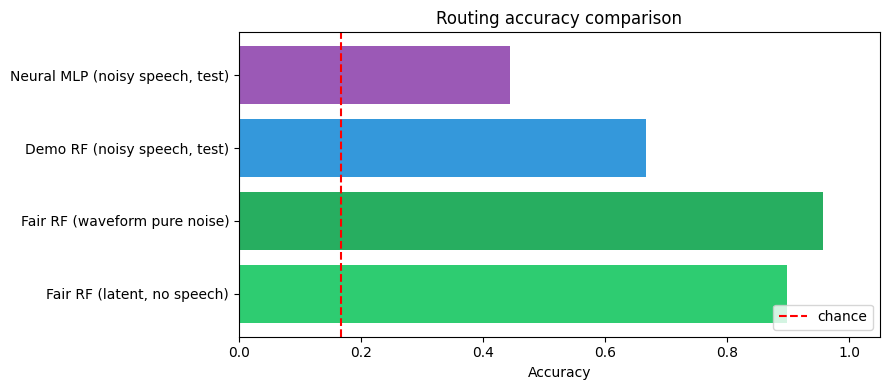

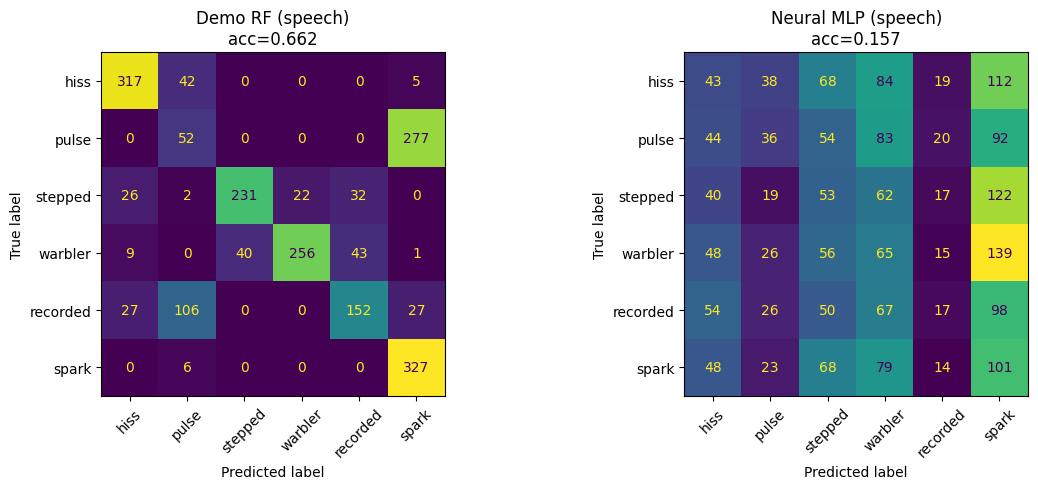


Neural — classification report:
              precision    recall  f1-score   support

        hiss       0.35      0.29      0.32       332
       pulse       0.24      0.12      0.16       348
     stepped       0.40      0.44      0.42       315
     warbler       0.72      0.93      0.81       337
    recorded       0.31      0.10      0.15       326
       spark       0.40      0.77      0.52       342

    accuracy                           0.44      2000
   macro avg       0.40      0.44      0.40      2000
weighted avg       0.40      0.44      0.40      2000


Demo RF — classification report:
              precision    recall  f1-score   support

        hiss       0.84      0.87      0.85       364
       pulse       0.25      0.16      0.19       329
     stepped       0.85      0.74      0.79       313
     warbler       0.92      0.73      0.82       349
    recorded       0.67      0.49      0.56       312
       spark       0.51      0.98      0.67       333

    accura

In [7]:
# --- 7. Routing comparison plots ---
results = {
    "Fair RF (latent, no speech)": acc_fair,
    "Fair RF (waveform pure noise)": acc_fair_wav,
    "Demo RF (noisy speech, test)": acc_demo_test,
    "Neural MLP (noisy speech, test)": acc_neural,
    "Chance (1/6)": 1.0 / NUM_FAMILIES,
}

print("=" * 72)
print("ROUTING SUMMARY")
print("=" * 72)
for k, v in results.items():
    print(f"  {k:<35} {v:.4f}")
print("=" * 72)

fig, ax = plt.subplots(figsize=(9, 4))
names = list(results.keys())[:-1]
vals = [results[k] for k in names]
colors = ["#2ecc71", "#27ae60", "#3498db", "#9b59b6"]
ax.barh(names, vals, color=colors)
ax.axvline(1 / NUM_FAMILIES, color="red", linestyle="--", label="chance")
ax.set_xlim(0, 1.05)
ax.set_xlabel("Accuracy")
ax.set_title("Routing accuracy comparison")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Confusion matrices: demo RF vs neural on same test frames
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, title in zip(axes, [p_demo, p_neural], ["Demo RF (speech)", "Neural MLP (speech)"]):
    cm = confusion_matrix(y_demo, pred, labels=list(range(NUM_FAMILIES)))
    ConfusionMatrixDisplay(cm, display_labels=CHANNEL_NAMES).plot(
        ax=ax, xticks_rotation=45, colorbar=False
    )
    ax.set_title(f"{title}\nacc={balanced_accuracy_score(y_demo, pred):.3f}")
plt.tight_layout()
plt.show()

print("\nNeural — classification report:")
print(classification_report(y_te, p_neural, target_names=CHANNEL_NAMES, zero_division=0))
print("\nDemo RF — classification report:")
print(classification_report(y_demo, p_demo, target_names=CHANNEL_NAMES, zero_division=0))


Batch routing accuracy (demo RF): 0.668
MSE noisy: 0.01440 | demo RF route: 0.01500 | oracle route: 0.01347


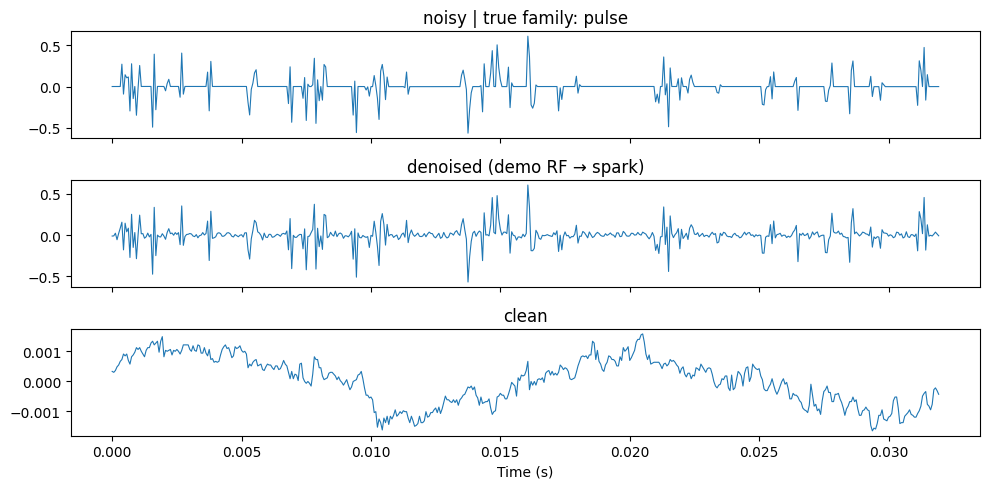

In [8]:
# --- 8. Denoise one batch with demo RF routing ---
import torch.nn.functional as F

model.eval()
noisy, clean, fam = next(iter(test_loader))
noisy = noisy.to(DEVICE)
route = predict_demo_route(demo_router, noisy)
with torch.no_grad():
    denoised = model.forward_with_route(noisy, route)
    oracle = model.forward_with_route(noisy, fam.to(DEVICE))

mse_noisy = F.mse_loss(noisy, clean.to(DEVICE)).item()
mse_demo = F.mse_loss(denoised, clean.to(DEVICE)).item()
mse_oracle = F.mse_loss(oracle, clean.to(DEVICE)).item()
route_acc_batch = (route.cpu() == fam).float().mean().item()
print(f"Batch routing accuracy (demo RF): {route_acc_batch:.3f}")
print(f"MSE noisy: {mse_noisy:.5f} | demo RF route: {mse_demo:.5f} | oracle route: {mse_oracle:.5f}")

i = 0
t = np.arange(FRAME_SIZE) / 16000
fig, ax = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
ax[0].plot(t, noisy[i].cpu().numpy(), lw=0.8)
ax[0].set_title(f"noisy | true family: {CHANNEL_NAMES[fam[i].item()]}")
ax[1].plot(t, denoised[i].cpu().numpy(), lw=0.8)
ax[1].set_title(f"denoised (demo RF → {CHANNEL_NAMES[route[i].item()]})")
ax[2].plot(t, clean[i].numpy(), lw=0.8)
ax[2].set_title("clean")
plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()


### Notes

- **`fair_router`** matches the adaptive notebook task: classify **pure latent noise** (no speech). Compare its accuracy to `Adaptive_Autoencoders_Project.ipynb` `noise_clf` results.
- **`demo_router`** is for **deployment**: route from **noisy speech** frames using spectral features.
- **`model(noisy)`** uses the built-in MLP router; for demos prefer `forward_with_route(..., predict_demo_route(noisy))`.
- Full training without `FAST_MODE`: `python run_moe_baseline.py` from the repo root.
- Package modules live under [`moe_baseline/`](moe_baseline/).
